## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [4]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: epsg:4326


In [9]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [10]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 52


In [11]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
21,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL521,Imathia,Ημαθία,2.0,2,1,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
22,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL522,Thessaloniki,Θεσσαλονίκη,2.0,1,1,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
23,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL523,Kilkis,Κιλκίς,4.0,3,2,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
25,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL525,Pieria,Πιερία,4.0,2,1,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


In [12]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: epsg:4326


<AxesSubplot:>

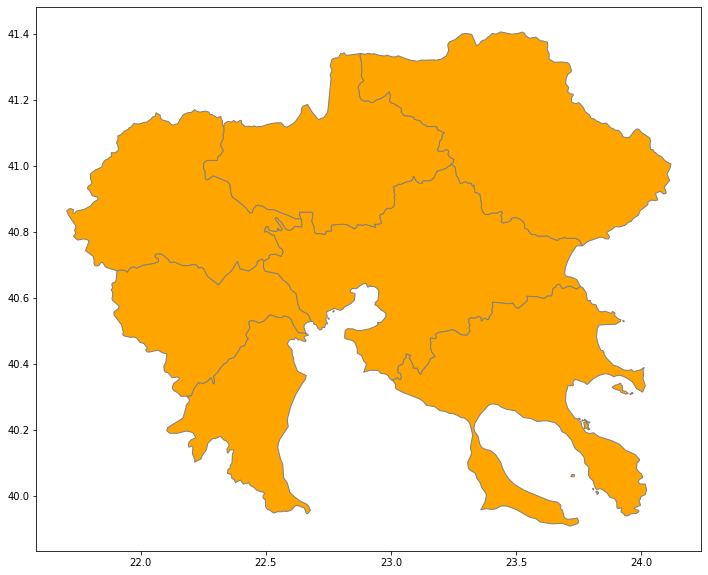

In [13]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [14]:
nuts2_gdf.NUTS3_NAME.unique()

array(['Ημαθία', 'Θεσσαλονίκη', 'Κιλκίς', 'Πέλλα', 'Πιερία', 'Σέρρες',
       'Χαλκιδική'], dtype=object)

In [15]:
nuts2_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_LATN','NUTS3_LATN',
                        'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS3_NAME')
process_greek(nuts2_gdf, 'NUTS2_NAME')

In [16]:
nuts2_gdf.head(5)

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,geometry
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL52,κεντρικη μακεδονια,EL523,κιλκις,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL52,κεντρικη μακεδονια,EL524,πελλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL52,κεντρικη μακεδονια,EL525,πιερια,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


<AxesSubplot:>

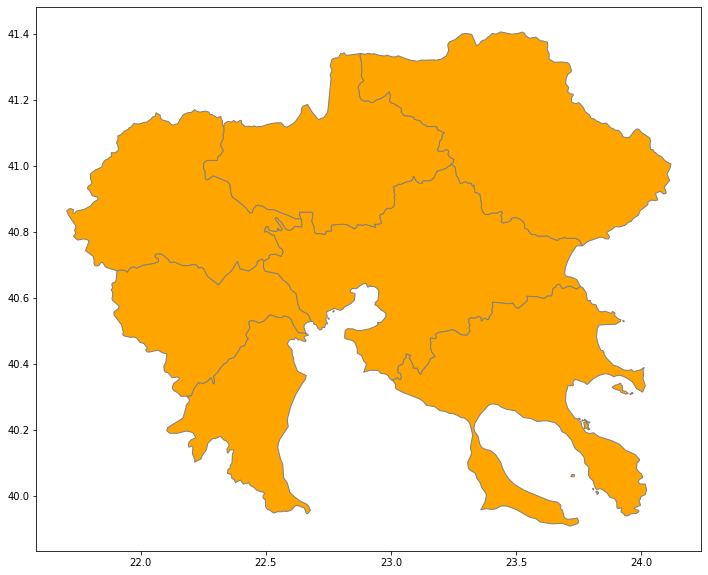

In [17]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [18]:
nuts3_units = nuts2_gdf['NUTS3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in CMacedonia (from shapefile): 7


In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [20]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS3_NAME', dimension=4.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [21]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((21.98826 40.50420, 21.98826 40.54462...",POINT (21.96175558936402 40.52441180855264),ημαθια,21.96176,40.52441
1,"POLYGON ((21.98826 40.54462, 21.98826 40.58505...",POINT (21.96175558936402 40.56483686465313),ημαθια,21.96176,40.56484
2,"POLYGON ((21.98826 40.58505, 21.98826 40.62547...",POINT (21.96175558936402 40.605261920753605),ημαθια,21.96176,40.60526
3,"POLYGON ((21.98826 40.62547, 21.98826 40.66590...",POINT (21.96175558936402 40.645686976854094),ημαθια,21.96176,40.64569
4,"POLYGON ((22.04127 40.50420, 22.04127 40.54462...",POINT (22.014761982273363 40.52441180855264),ημαθια,22.01476,40.52441


In [22]:
df_grid.rename(columns={"NAME": "NUTS3_NAME"}, inplace = True)

<AxesSubplot:>

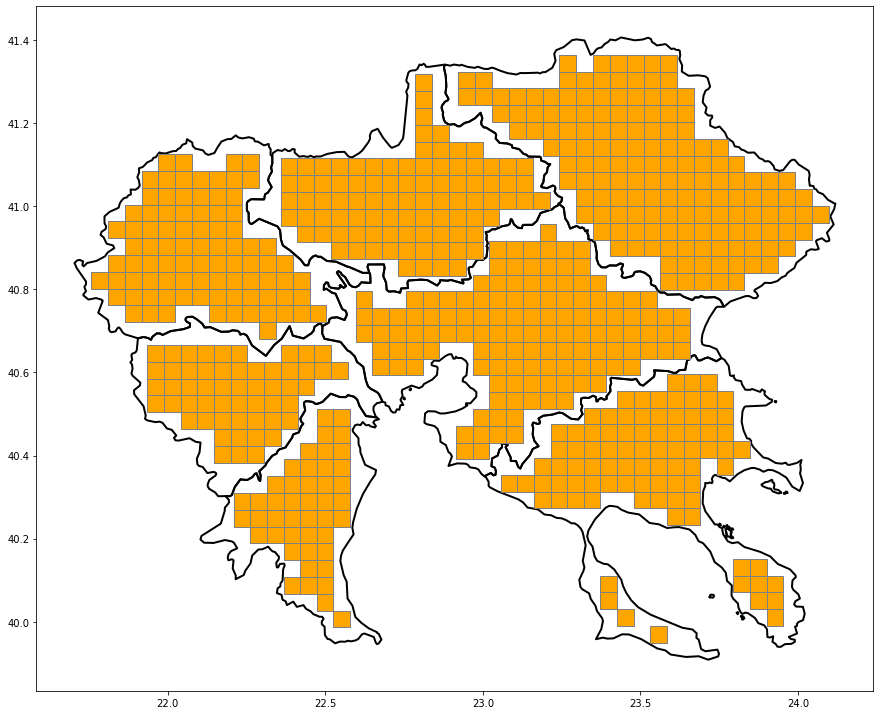

In [23]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 7


In [25]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['NUTS3_NAME'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['NUTS3_NAME'] = lost_lau1['NUTS3_NAME']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [26]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [27]:
nuts2_grid

,geometry,NUTS3_NAME,x,y
0,"POLYGON ((21.98826 40.50420, 21.98826 40.54462...",ημαθια,21.96176,40.52441
1,"POLYGON ((21.98826 40.54462, 21.98826 40.58505...",ημαθια,21.96176,40.56484
2,"POLYGON ((21.98826 40.58505, 21.98826 40.62547...",ημαθια,21.96176,40.60526
3,"POLYGON ((21.98826 40.62547, 21.98826 40.66590...",ημαθια,21.96176,40.64569
4,"POLYGON ((22.04127 40.50420, 22.04127 40.54462...",ημαθια,22.01476,40.52441
...,...,...,...,...
642,"POLYGON ((23.90007 40.07041, 23.90007 40.11084...",χαλκιδικη,23.87372,40.09062
643,"POLYGON ((23.90007 40.11084, 23.90007 40.15126...",χαλκιδικη,23.87372,40.13105
644,"POLYGON ((23.95277 39.98956, 23.95277 40.02999...",χαλκιδικη,23.92642,40.00977
645,"POLYGON ((23.95277 40.02999, 23.95277 40.07041...",χαλκιδικη,23.92642,40.05020


In [28]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [29]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
nuts2_grid

,shape,NUTS3_NAME,x,y
0,"POLYGON ((21.98826 40.50420, 21.98826 40.54462...",ημαθια,21.96176,40.52441
1,"POLYGON ((21.98826 40.54462, 21.98826 40.58505...",ημαθια,21.96176,40.56484
2,"POLYGON ((21.98826 40.58505, 21.98826 40.62547...",ημαθια,21.96176,40.60526
3,"POLYGON ((21.98826 40.62547, 21.98826 40.66590...",ημαθια,21.96176,40.64569
4,"POLYGON ((22.04127 40.50420, 22.04127 40.54462...",ημαθια,22.01476,40.52441
...,...,...,...,...
642,"POLYGON ((23.90007 40.07041, 23.90007 40.11084...",χαλκιδικη,23.87372,40.09062
643,"POLYGON ((23.90007 40.11084, 23.90007 40.15126...",χαλκιδικη,23.87372,40.13105
644,"POLYGON ((23.95277 39.98956, 23.95277 40.02999...",χαλκιδικη,23.92642,40.00977
645,"POLYGON ((23.95277 40.02999, 23.95277 40.07041...",χαλκιδικη,23.92642,40.05020


In [31]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [32]:
nuts2_grid_points

,shape,NUTS3_NAME,x,y,geometry
0,"POLYGON ((21.98826 40.50420, 21.98826 40.54462...",ημαθια,21.96176,40.52441,POINT (21.96176 40.52441)
1,"POLYGON ((21.98826 40.54462, 21.98826 40.58505...",ημαθια,21.96176,40.56484,POINT (21.96176 40.56484)
2,"POLYGON ((21.98826 40.58505, 21.98826 40.62547...",ημαθια,21.96176,40.60526,POINT (21.96176 40.60526)
3,"POLYGON ((21.98826 40.62547, 21.98826 40.66590...",ημαθια,21.96176,40.64569,POINT (21.96176 40.64569)
4,"POLYGON ((22.04127 40.50420, 22.04127 40.54462...",ημαθια,22.01476,40.52441,POINT (22.01476 40.52441)
...,...,...,...,...,...
642,"POLYGON ((23.90007 40.07041, 23.90007 40.11084...",χαλκιδικη,23.87372,40.09062,POINT (23.87372 40.09062)
643,"POLYGON ((23.90007 40.11084, 23.90007 40.15126...",χαλκιδικη,23.87372,40.13105,POINT (23.87372 40.13105)
644,"POLYGON ((23.95277 39.98956, 23.95277 40.02999...",χαλκιδικη,23.92642,40.00977,POINT (23.92642 40.00977)
645,"POLYGON ((23.95277 40.02999, 23.95277 40.07041...",χαλκιδικη,23.92642,40.05020,POINT (23.92642 40.05020)


<AxesSubplot:>

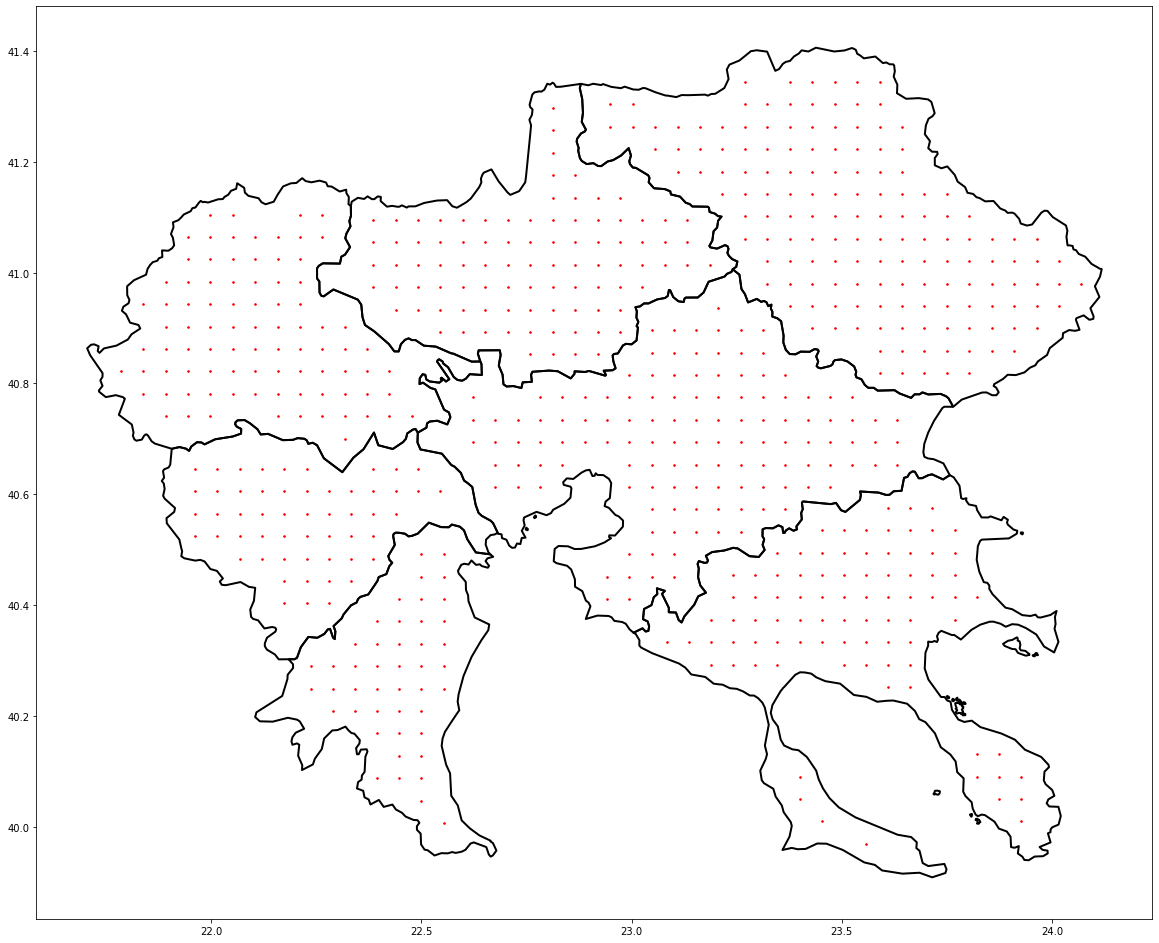

In [33]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [34]:
final_grid = pd.merge(nuts2_grid[['NUTS3_NAME', 'x', 'y']], nuts2_gdf[['NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], how='left', on=['NUTS3_NAME']) 
final_grid.sort_values(by=['NUTS3_NAME'], inplace = True)
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [35]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.96176,40.52441
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.56484
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.60526
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.22679,40.64569
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.27979,40.40314
...,...,...,...,...,...,...
642,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.37360
643,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.33318
644,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.39941,40.09062
645,EL52,κεντρικη μακεδονια,EL527,χαλκιδικη,23.55751,39.96935


In [36]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)